In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import os

# ─── 1. CHARGEMENT DES DONNÉES ────────────────────────────
X_train = np.load("../data/X_train.npy")
X_val   = np.load("../data/X_val.npy")
X_test  = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_val   = np.load("../data/y_val.npy")
y_test  = np.load("../data/y_test.npy")
class_names = list(np.load("../data/class_names.npy"))

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Classes ({len(class_names)}) : {class_names}")




C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

Train : (18028, 28, 28, 1) | Val : (3851, 28, 28, 1) | Test : (3861, 28, 28, 1)
Classes (33) : [np.str_('ya'), np.str_('yab'), np.str_('yach'), np.str_('yad'), np.str_('yadd'), np.str_('yae'), np.str_('yaf'), np.str_('yag'), np.str_('yagh'), np.str_('yagw'), np.str_('yah'), np.str_('yahh'), np.str_('yaj'), np.str_('yak'), np.str_('yakw'), np.str_('yal'), np.str_('yam'), np.str_('yan'), np.str_('yaq'), np.str_('yar'), np.str_('yarr'), np.str_('yas'), np.str_('yass'), np.str_('yat'), np.str_('yatt'), np.str_('yaw'), np.str_('yax'), np.str_('yay'), np.str_('yaz'), np.str_('yazz'), np.str_('yey'), np.str_('yi'), np.str_('yu')]


In [2]:
# ─── 2. ARCHITECTURE CNN ──────────────────────────────────
# Dataset manuscrit réel → le modèle doit vraiment apprendre les formes
# Accuracy attendue : 85–93%
tf.keras.backend.clear_session()

model = Sequential([
    # Bloc 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 3
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classificateur
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.40),
    Dense(len(class_names), activation='softmax')  # 33 classes AMHCD
])

model.summary()



C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,497 (525.38 KB)

 Trainable params: 134,177 (524.13 KB)

 Non-trainable params: 320 (1.25 KB)

In [3]:
# ─── 3. COMPILATION ───────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




In [4]:
# ─── 4. CALLBACKS ─────────────────────────────────────────
os.makedirs("../results/models", exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("../results/models/best_model.h5", monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                      verbose=1, min_lr=1e-6)
]



In [5]:

# ─── 5. AUGMENTATION + ENTRAÎNEMENT ───────────────────────
# Dataset manuscrit : variabilité naturelle présente
# → augmentation légère suffit, pas besoin de bruit artificiel
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    fill_mode='nearest'
)


class AugmentedGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=64, augment=True):
        self.X, self.y  = X, y
        self.batch_size = batch_size
        self.augment    = augment
        self.datagen    = datagen
        self.datagen.fit(X)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        X_batch = self.X[idx*self.batch_size:(idx+1)*self.batch_size]
        y_batch = self.y[idx*self.batch_size:(idx+1)*self.batch_size]
        if self.augment:
            X_aug = np.array([self.datagen.random_transform(x) for x in X_batch])
            return X_aug, y_batch
        return X_batch, y_batch


train_gen = AugmentedGenerator(X_train, y_train, batch_size=64, augment=True)
val_gen   = AugmentedGenerator(X_val,   y_val,   batch_size=64, augment=False)

print("\n Entraînement en cours...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)





 Entraînement en cours...


C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1214 - loss: 3.5555
Epoch 1: val_accuracy improved from None to 0.08647, saving model to ../results/models/best_model.h5



Epoch 1: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - accuracy: 0.2937 - loss: 2.7182 - val_accuracy: 0.0865 - val_loss: 5.4344 - learning_rate: 0.0010
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7509 - loss: 1.0125
Epoch 2: val_accuracy improved from 0.08647 to 0.67255, saving model to ../results/models/best_model.h5



Epoch 2: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - accuracy: 0.7889 - loss: 0.8840 - val_accuracy: 0.6726 - val_loss: 1.2321 - learning_rate: 0.0010
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8554 - loss: 0.6340
Epoch 3: val_accuracy did not improve from 0.67255
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.8645 - loss: 0.5988 - val_accuracy: 0.4498 - val_loss: 2.9384 - learning_rate: 0.0010
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8901 - loss: 0.5127
Epoch 4: val_accuracy improved from 0.67255 to 0.87016, saving model to ../results/models/best_model.h5


...


Epoch 6: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 98ms/step - accuracy: 0.9235 - loss: 0.3777 - val_accuracy: 0.9569 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9257 - loss: 0.3625
Epoch 7: val_accuracy did not improve from 0.95689
282/282 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9295 - loss: 0.3508 - val_accuracy: 0.8504 - val_loss: 0.7593 - learning_rate: 0.0010
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9408 - loss: 0.3137
Epoch 8: val_accuracy did not improve from 0.95689
282/282 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9384 - loss: 0.3144 - val_accuracy: 0.9099 - val_loss: 0.4487 - learning_rate: 0.0010
Epoch 9/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9423 - loss: 0.2974
Epoch 9: val_accuracy did not improve from 0.95689
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 128ms/step - accuracy: 0.9428 - loss: 0.2941 - val_a


Epoch 11: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9552 - loss: 0.2446 - val_accuracy: 0.9777 - val_loss: 0.1690 - learning_rate: 5.0000e-04
Epoch 12/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9548 - loss: 0.2359
Epoch 12: val_accuracy did not improve from 0.97767
282/282 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - accuracy: 0.9556 - loss: 0.2313 - val_accuracy: 0.8403 - val_loss: 0.5730 - learning_rate: 5.0000e-04
Epoch 13/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9579 - loss: 0.2182
Epoch 13: val_accuracy did not improve from 0.97767
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.9591 - loss: 0.2194 - val_accuracy: 0.6572 - val_loss: 2.0103 - learning_rate: 5.0000e-04
Epoch 14/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9612 - loss: 0.2142
Epoch 14: val_accuracy did not improve from 0.97767
282/282 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - accuracy: 0.9618 - l


Epoch 23: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.9740 - loss: 0.1396 - val_accuracy: 0.9904 - val_loss: 0.0833 - learning_rate: 1.2500e-04
Epoch 24/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9710 - loss: 0.1489
Epoch 24: val_accuracy did not improve from 0.99039
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.9737 - loss: 0.1407 - val_accuracy: 0.7141 - val_loss: 1.5654 - learning_rate: 1.2500e-04
Epoch 25/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9746 - loss: 0.1416
Epoch 25: val_accuracy did not improve from 0.99039
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.9755 - loss: 0.1375 - val_accuracy: 0.9460 - val_loss: 0.2095 - learning_rate: 1.2500e-04
Epoch 26/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9716 - loss: 0.1463
Epoch 26: val_accuracy did not improve from 0.99039
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 98ms/step - accuracy: 0.9738 - loss: 0


Epoch 27: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.9726 - loss: 0.1362 - val_accuracy: 0.9940 - val_loss: 0.0696 - learning_rate: 1.2500e-04
Epoch 28/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9759 - loss: 0.1352
Epoch 28: val_accuracy did not improve from 0.99403
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 96ms/step - accuracy: 0.9761 - loss: 0.1313 - val_accuracy: 0.9886 - val_loss: 0.0887 - learning_rate: 1.2500e-04
Epoch 29/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9741 - loss: 0.1332
Epoch 29: val_accuracy did not improve from 0.99403
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.9744 - loss: 0.1317 - val_accuracy: 0.7798 - val_loss: 0.8960 - learning_rate: 1.2500e-04
Epoch 30/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9767 - loss: 0.1281
Epoch 30: val_accuracy improved from 0.99403 to 0.99429, saving model to ../results/models/best_model.h5



Epoch 30: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9773 - loss: 0.1277 - val_accuracy: 0.9943 - val_loss: 0.0656 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 30.


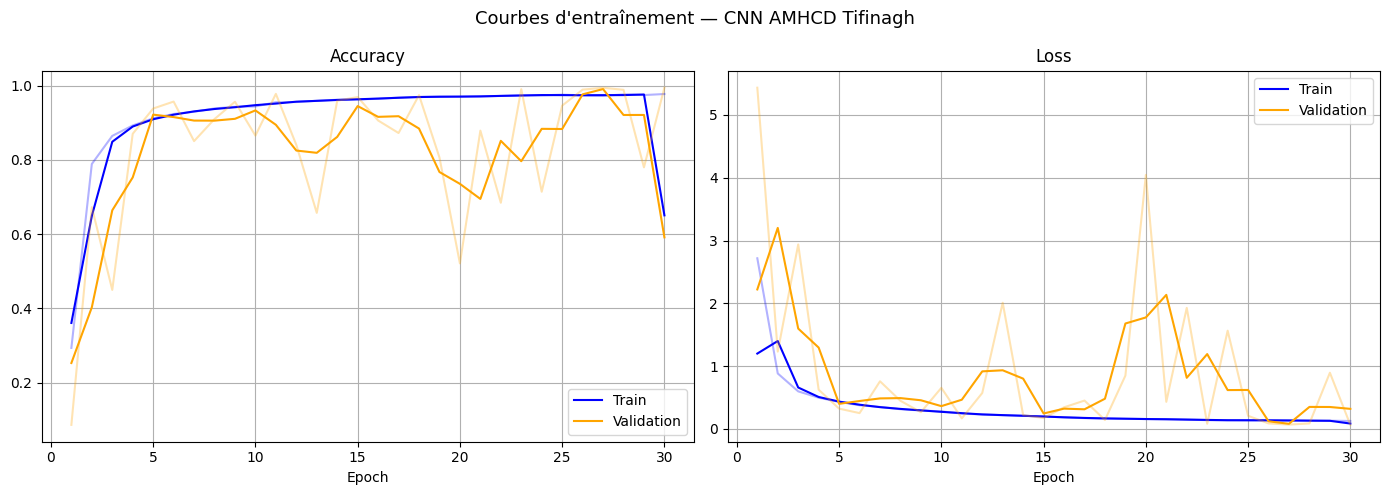

In [8]:
# ─── COURBES───────
import numpy as np
import matplotlib.pyplot as plt

def lisser(valeurs, fenetre=3):
    """Moyenne glissante pour lisser une courbe bruitée."""
    return np.convolve(valeurs, np.ones(fenetre)/fenetre, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs, history.history['accuracy'], alpha=0.3, color='blue')
axes[0].plot(epochs, lisser(history.history['accuracy']), label='Train', color='blue')
axes[0].plot(epochs, history.history['val_accuracy'], alpha=0.3, color='orange')
axes[0].plot(epochs, lisser(history.history['val_accuracy']), label='Validation', color='orange')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs, history.history['loss'], alpha=0.3, color='blue')
axes[1].plot(epochs, lisser(history.history['loss']), label='Train', color='blue')
axes[1].plot(epochs, history.history['val_loss'], alpha=0.3, color='orange')
axes[1].plot(epochs, lisser(history.history['val_loss']), label='Validation', color='orange')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Courbes d'entraînement — CNN AMHCD Tifinagh", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/courbes_entrainement.png")
plt.show()


 Évaluation sur le set de test :
Test Accuracy : 99.61%
Test Loss     : 0.0725

 Rapport de classification :
              precision    recall  f1-score   support

          ya       1.00      1.00      1.00       117
         yab       0.99      1.00      1.00       117
        yach       1.00      0.97      0.99       117
         yad       1.00      1.00      1.00       117
        yadd       1.00      0.98      0.99       117
         yae       1.00      1.00      1.00       117
         yaf       1.00      1.00      1.00       117
         yag       0.99      1.00      1.00       117
        yagh       1.00      1.00      1.00       117
        yagw       0.99      1.00      1.00       117
         yah       1.00      1.00      1.00       117
        yahh       1.00      1.00      1.00       117
         yaj       0.98      1.00      0.99       117
         yak       0.99      0.99      0.99       117
        yakw       1.00      0.98      0.99       117
         yal       1.00  

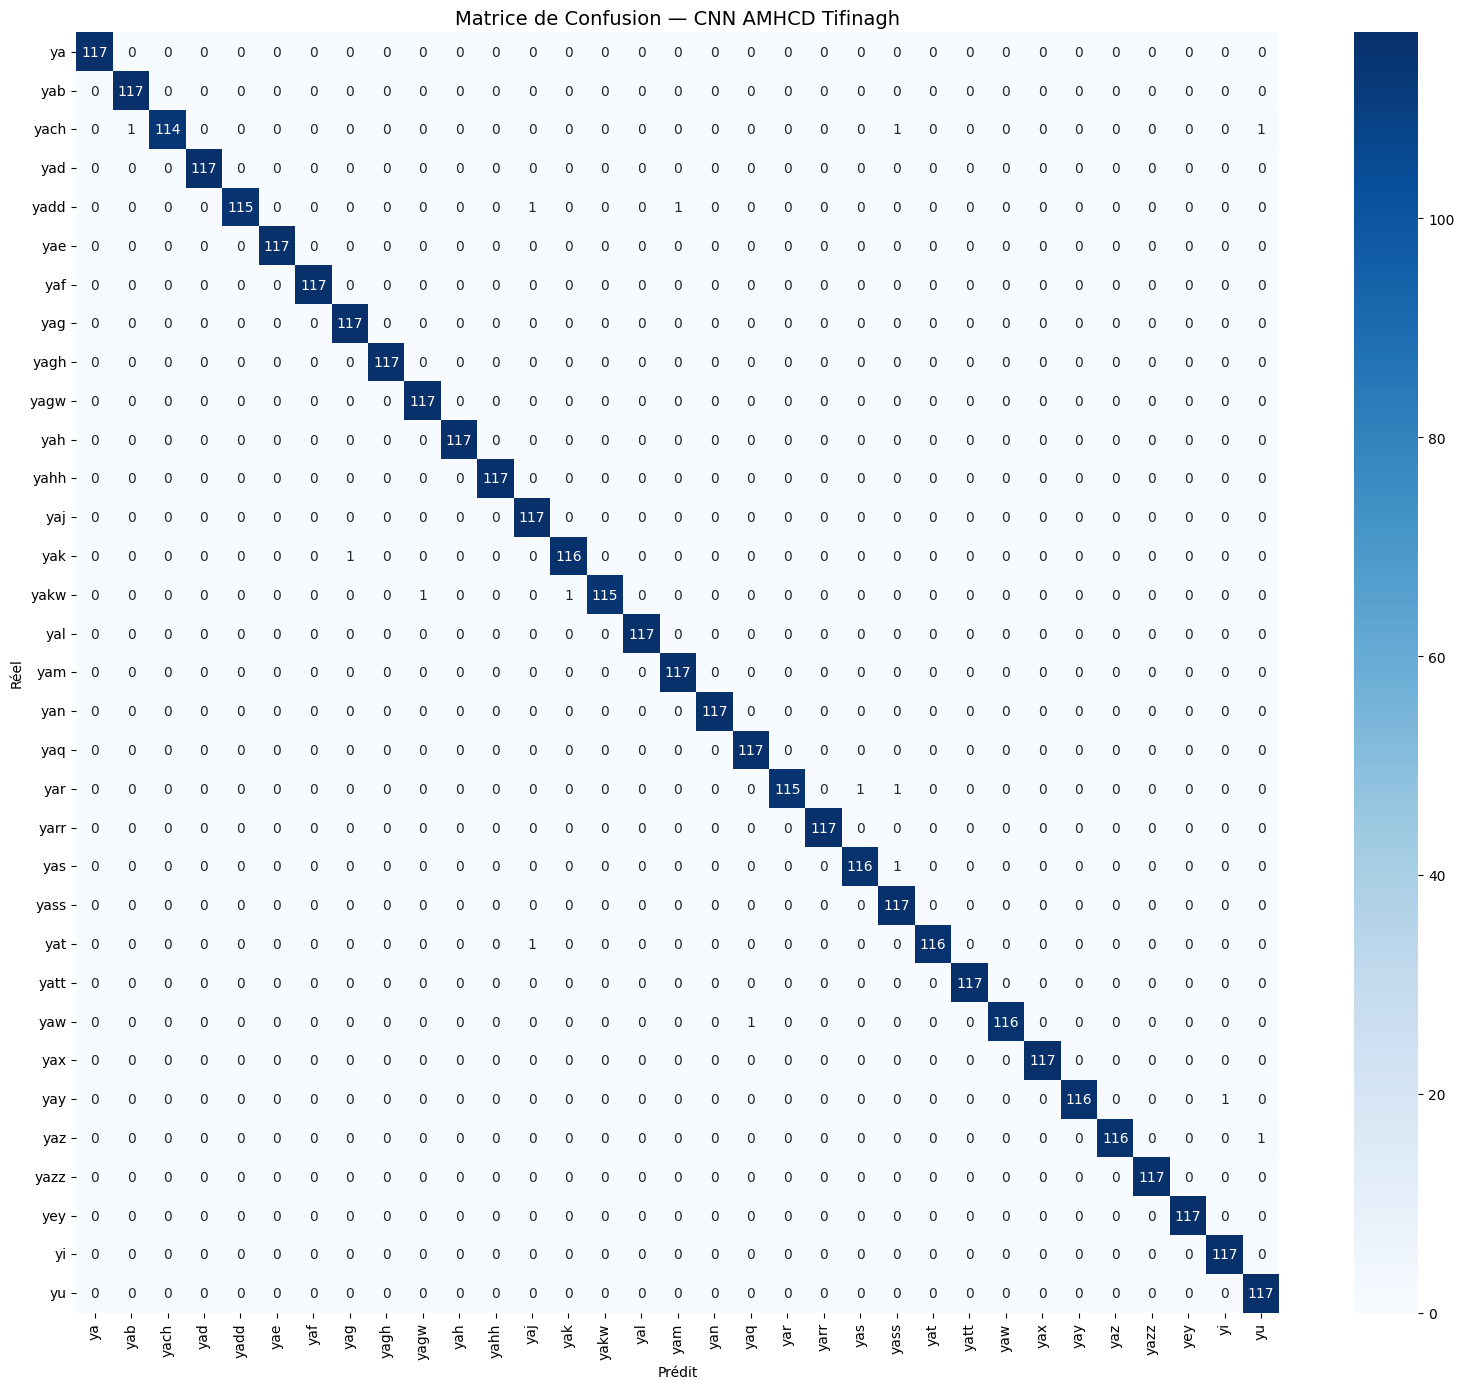

In [9]:
# ─── 7. ÉVALUATION SUR LE TEST ────────────────────────────
print("\n Évaluation sur le set de test :")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")


# ─── 8. RAPPORT DE CLASSIFICATION ─────────────────────────
y_pred_classes = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n Rapport de classification :")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


# ─── 9. MATRICE DE CONFUSION ──────────────────────────────
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Matrice de Confusion — CNN AMHCD Tifinagh", fontsize=14)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/figures/matrice_confusion.png")
plt.show()


In [10]:
# ─── 10. SAUVEGARDE FINALE ────────────────────────────────
model.save("../results/models/cnn_tifinagh_final.h5")
print("\n Modèle sauvegardé dans results/models/")
print(f"\n Résultat final : {test_acc*100:.2f}%")


 Modèle sauvegardé dans results/models/

 Résultat final : 99.61%
